**Install the required libraries**

In [ ]:
# Install libraries to use matminer.
!pip install pyyaml -q
!pip install six -q
!pip install matminer[citrine] -q
!pip install citrination-client -q
!pip install --upgrade pandas==2.2.2 -q
!pip install pymatgen -q
!pip install --upgrade matplotlib==3.8.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.4/561.4 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.8/117.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.

# **1. Train and Test ML algorithm: California house price case**

**Loading libraries we want to use in this notebook**

(you don't need to load all of libraries at first and you can load it anytime and anywhere)

In [ ]:
import pandas as pd # a software library written for the Python programming language for data manipulation and analysis. In particular, it offers data structures and operations for manipulating numerical tables and time series
import seaborn as sns # Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import numpy as np # a software library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays.
import matplotlib.pyplot as plt # a plotting library for the Python programming language

# sklearn is a machine learning software library for the Python programming language. It features various classification, regression and clustering algorithms including support vector machines, random forests, gradient boosting,
# k-means and DBSCAN, and is designed to interoperate with the Python numerical and scientific libraries NumPy and SciPy.
from sklearn.datasets import fetch_california_housing
from sklearn import linear_model, metrics, model_selection
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression

Loading the boston house-prices dataset from the sklearn repository

In [ ]:
# Load the California housing dataset
california = fetch_california_housing()

In [ ]:
# Print the key values of data
print(california.keys())
# Print the total row and column length of the dataset
print(california.data.shape)
# Print feature names
print(california.feature_names)

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
(20640, 8)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Check the description of dataset

In [ ]:
# Check the description of dataset
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
df = pd.DataFrame(california.data)
df.head()

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# Enter feature as the column name
df.columns = california.feature_names
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# Put the targetP('Price') in the dataset
df['Price'] = california.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Feature selection**

Sometimes, the input variables may not be directly related to the interested target. Hence, a feature selection step is necessary. There are many different methods for selecting features. Here we will go over a simple implementation in scikit-learn.

In [ ]:
# Function that returns feature names
def identify_columns(x_new, nrows=10):
    columns = x_data.columns
    xvalues = x_data.values
    dist = np.linalg.norm(xvalues[:nrows, :, None] - x_new[:nrows, None, :], axis=0)
    return columns[np.argmin(dist, axis=0)].values

In [ ]:
# # x_data contains the features('california.feature_names')
x_data = df[california.feature_names]

# y_data contains the target variable('Price')
y_data = df['Price']

In [ ]:
# Select the top 5 features by using 'SelectKBest'
sel = SelectKBest(f_regression, k=5)
x_new = sel.fit_transform(x_data, y_data)
print(f"Selected features {identify_columns(x_new)}")

Selected features ['MedInc' 'HouseAge' 'AveRooms' 'AveBedrms' 'Latitude']


**1. Train ML algorithm**

<ipython-input-13-8d29d4dde486>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(20, 4, "Price = {:.3f} * AveRooms + {:.3f}".format(float(a), float(b)) , fontsize=15, color = "r")


Text(20, 4, 'Price = 0.071 * AveRooms + 1.684')

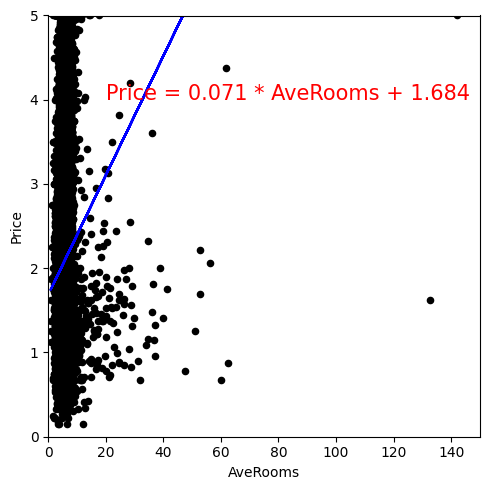

In [ ]:
# Train about the average number of rooms and house prices by using 'LinearRegression'
linear_regression = linear_model.LinearRegression()
linear_regression.fit(X=pd.DataFrame(df['AveRooms']), y=df['Price'])
prediction = linear_regression.predict(X=pd.DataFrame(df['AveRooms']))

# Get the slope and intercept from the trained linear regression model
a = linear_regression.coef_
b = linear_regression.intercept_
df.plot(kind='scatter', x ="AveRooms", y="Price", figsize=(5, 5), color='black', xlim=(0,150), ylim=(0,5))
plt.tight_layout()
plt.plot(df['AveRooms'], prediction, color='b')
plt.text(20, 4, "Price = {:.3f} * AveRooms + {:.3f}".format(float(a), float(b)) , fontsize=15, color = "r")

**2. Train & Test ML algorithm**



In [ ]:
# Classify into training dataset and testing dataset using only "AveRooms" feature
x_data = df[['AveRooms']]
y_data = df['Price']

# Split the data into training and test sets('train_test_split')
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_data, y_data, test_size=0.1)
print("Size of training set: {}, test set: {}".format(len(x_train), len(x_test)))

Size of training set: 18576, test set: 2064


score: 0.03
Mean Squared Error: 1.34
RMSE (* 1000$): 1.16


(0.0, 10.0)

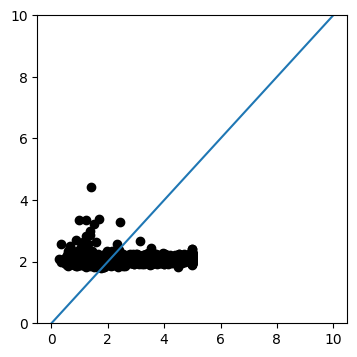

In [ ]:
# Train Linear regression model('fit')
estimator = linear_model.LinearRegression()
estimator.fit(X=x_train, y=y_train)

# Test with prediction by using R2 score('metrics.r2_score')
y_predict_test = estimator.predict(x_test)
score = metrics.r2_score(y_test, y_predict_test)

print('score: {:.2f}'.format(float(score)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_predict_test, y_test)))
print('RMSE (* 1000$): {:.2f}'.format(metrics.mean_squared_error(y_predict_test, y_test)**.5))

# Print prediction values about test set
plt.figure(figsize=(4,4))
plt.scatter(y_test, y_predict_test, color='k')
plt.plot([0,10],[0,10])
plt.ylim(0, 10)
plt.ylim(0, 10)

score: 0.60
Mean Squared Error: 0.54
RMSE (* 1000$): 0.74


(0.0, 10.0)

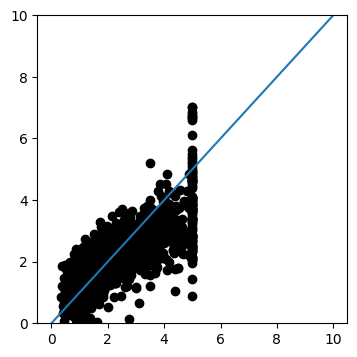

In [ ]:
# Train with all features('california.feature_names')
x_data = df[california.feature_names]
y_data = df['Price']
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_data, y_data, test_size=0.1)

estimator = linear_model.LinearRegression()
estimator.fit(x_train, y_train)

#y_predict_train = estimator.predict(x_train)
#score = metrics.r2_score(y_train, y_predict_train)
#print(score) #1.0

y_predict_test = estimator.predict(x_test)
score = metrics.r2_score(y_test, y_predict_test)

print('score: {:.2f}'.format(float(score)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_predict_test, y_test)))
print('RMSE (* 1000$): {:.2f}'.format(metrics.mean_squared_error(y_predict_test, y_test)**.5))

plt.figure(figsize=(4,4))
plt.scatter(y_test, y_predict_test, color='k')
plt.plot([0,10],[0,10])
plt.ylim(0, 10)
plt.ylim(0, 10)

Benchmark the optimial number of features

Selected 1 features ['MedInc']
Selected 2 features ['MedInc' 'AveRooms']
Selected 3 features ['MedInc' 'AveRooms' 'Latitude']
Selected 4 features ['MedInc' 'HouseAge' 'AveRooms' 'Latitude']
Selected 5 features ['MedInc' 'HouseAge' 'AveRooms' 'AveBedrms' 'Latitude']
Selected 6 features ['MedInc' 'HouseAge' 'AveRooms' 'AveBedrms' 'Latitude' 'Longitude']
Selected 7 features ['MedInc' 'HouseAge' 'AveRooms' 'AveBedrms' 'Population' 'Latitude'
 'Longitude']
Selected 8 features ['MedInc' 'HouseAge' 'AveRooms' 'AveBedrms' 'Population' 'AveOccup'
 'Latitude' 'Longitude']


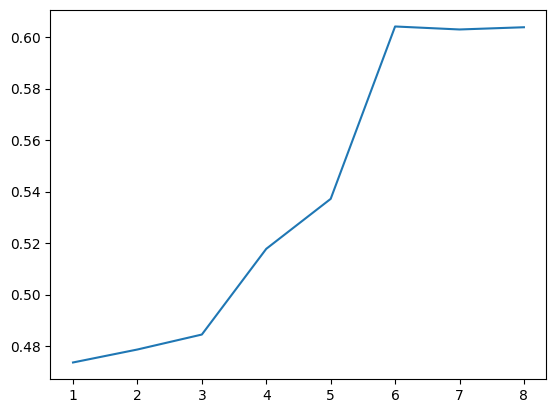

In [ ]:
# Searching the optimal number of features by predicting R2 score while increasing the number of features
all = []
for i in range(1,len(california.feature_names)+1):
  sum_score = 0
  sum_mse = 0
  sum_rmse = 0
  x_data = df[california.feature_names]
  y_data = df['Price']
  sel = SelectKBest(f_regression, k=i)
  x_new = sel.fit_transform(x_data, y_data)
  selected = identify_columns(x_new)
  print(f"Selected {i} features {selected}")
  x_data = df[selected]
  y_data = df['Price']
  # To consider changes of R2 score depending on random train set data due to the small number of data,
  # evaluate with the average of R2 score from 1000 iterations of training about the each number of features
  for j in range(1001):
    x_train, x_test, y_train, y_test = model_selection.train_test_split(x_data, y_data, test_size=0.1)
    estimator = linear_model.LinearRegression()
    estimator.fit(x_train, y_train)
    y_predict_test = estimator.predict(x_test)
    sum_score += float(metrics.r2_score(y_test, y_predict_test))
    sum_mse += float(metrics.mean_squared_error(y_predict_test, y_test))
    sum_rmse += float(metrics.mean_squared_error(y_predict_test, y_test)**.5)
 # print('average of score: {:.2f}'.format(sum_score/10))
 # print('average of Mean Squared Error: {:.2f}'.format(sum_mse/10))
 # print('average of RMSE (* 1000$): {:.2f}'.format(sum_rmse/10))
  all.append(sum_score/1000)
plt.plot([i for i in range(1, len(all)+1)], all)

**Benchmark the score (R2) with other various regression ML algorithm (LASSO, Ridge, Random Forest Tree)**

R2 score—varies between 0 and 100%. It is closely related to the mean square error, but not the same. R2 is the proportion of the variance in the dependent variable that is predictable from the independent variable(s). Another definition is “(total variance explained by model) / total variance.” So if it is 100%, the two variables are perfectly correlated, i.e., with no variance at all. A low value would show a low level of correlation, meaning a regression model that is not valid , but not in all cases.

Selected 1 features ['MedInc']
average of score: 44.82
average of Mean Squared Error: 73.52
average of RMSE (* 1000$): 85.77
Selected 2 features ['MedInc' 'AveRooms']
average of score: 44.84
average of Mean Squared Error: 73.60
average of RMSE (* 1000$): 85.81
Selected 3 features ['MedInc' 'AveRooms' 'Latitude']
average of score: 44.83
average of Mean Squared Error: 73.51
average of RMSE (* 1000$): 85.77
Selected 4 features ['MedInc' 'HouseAge' 'AveRooms' 'Latitude']
average of score: 48.14
average of Mean Squared Error: 69.13
average of RMSE (* 1000$): 83.17
Selected 5 features ['MedInc' 'HouseAge' 'AveRooms' 'AveBedrms' 'Latitude']
average of score: 48.17
average of Mean Squared Error: 69.06
average of RMSE (* 1000$): 83.13
Selected 6 features ['MedInc' 'HouseAge' 'AveRooms' 'AveBedrms' 'Latitude' 'Longitude']
average of score: 48.06
average of Mean Squared Error: 69.22
average of RMSE (* 1000$): 83.22
Selected 7 features ['MedInc' 'HouseAge' 'AveRooms' 'AveBedrms' 'Population' 'Lati

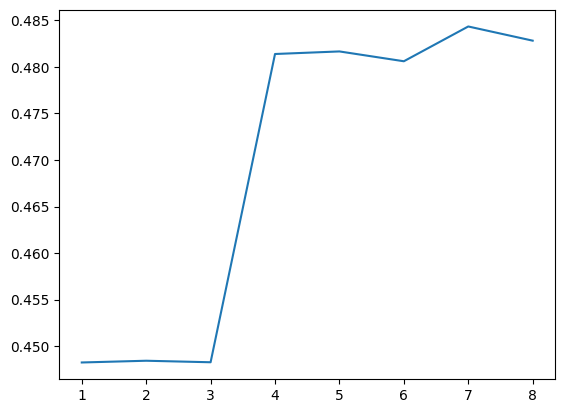

In [ ]:
all = []
for i in range(1,len(california.feature_names)+1):
  sum_score = 0
  sum_mse = 0
  sum_rmse = 0
  x_data = df[california.feature_names]
  y_data = df['Price']
  sel = SelectKBest(f_regression, k=i)
  x_new = sel.fit_transform(x_data, y_data)
  selected = identify_columns(x_new)
  print(f"Selected {i} features {selected}")
  x_data = df[selected]
  y_data = df['Price']
  for j in range(1001):
    x_train, x_test, y_train, y_test = model_selection.train_test_split(x_data, y_data, test_size=0.1)

    # For 'Lasso' regression
    estimator = linear_model.Lasso(alpha=0.35, max_iter=1000, tol=0.0001)
    # estimator = linear_model.Ridge(alpha=1)  # For Ridge regression
    # estimator = RandomForestRegressor()  # For Random forest regressor

    estimator.fit(x_train, y_train)
    y_predict_test = estimator.predict(x_test)
    sum_score += float(metrics.r2_score(y_test, y_predict_test))
    sum_mse += float(metrics.mean_squared_error(y_predict_test, y_test))
    sum_rmse += float(metrics.mean_squared_error(y_predict_test, y_test)**.5)
  print('average of score: {:.2f}'.format(sum_score/10))
  print('average of Mean Squared Error: {:.2f}'.format(sum_mse/10))
  print('average of RMSE (* 1000$): {:.2f}'.format(sum_rmse/10))
  all.append(sum_score/1000)
plt.plot([i for i in range(1, len(all)+1)], all)

# **2. Train and Test ML algorithm in Materials - Supervised Learning**

**Load and prepare a pre-featurized dataset**

In [ ]:
# Install libraries to use matminer.
!pip install --upgrade matplotlib==3.8.0 -q
!pip install --upgrade pyyaml six matminer[citrine] citrination-client pymatgen -q
!pip install --upgrade pandas==2.2.2 -q

In [ ]:
from matminer.datasets.convenience_loaders import load_elastic_tensor

df = load_elastic_tensor()  # load the dataset in a pandas DataFrame object
df.columns # check columns

Fetching elastic_tensor_2015.json.gz from https://ndownloader.figshare.com/files/13220603 to /usr/local/lib/python3.10/dist-packages/matminer/datasets/elastic_tensor_2015.json.gz


Fetching https://ndownloader.figshare.com/files/13220603 in MB: 1.1182079999999999MB [00:00, 161.21MB/s]                


Index(['material_id', 'formula', 'nsites', 'space_group', 'volume',
       'structure', 'elastic_anisotropy', 'G_Reuss', 'G_VRH', 'G_Voigt',
       'K_Reuss', 'K_VRH', 'K_Voigt', 'poisson_ratio', 'compliance_tensor',
       'elastic_tensor', 'elastic_tensor_original'],
      dtype='object')

In [ ]:
# Removing unneeded columns from the data set
# Not all data is required for modeling.
unwanted_columns = ["volume", "nsites", "compliance_tensor", "elastic_tensor",
                    "elastic_tensor_original", "K_Voigt", "G_Voigt", "K_Reuss", "G_Reuss"]
df = df.drop(unwanted_columns, axis=1)
df.head()

,material_id,formula,space_group,structure,elastic_anisotropy,G_VRH,K_VRH,poisson_ratio
0,mp-10003,Nb4CoSi,124,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",0.030688,97.141604,194.268884,0.285701
1,mp-10010,Al(CoSi)2,164,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",0.266910,96.252006,175.449907,0.268105
2,mp-10015,SiOs,221,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",0.756489,130.112955,295.077545,0.307780
3,mp-10021,Ga,63,"[[0. 1.09045794 0.84078375] Ga, [0. ...",2.376805,15.101901,49.130670,0.360593
4,mp-10025,SiRu2,62,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",0.196930,101.947798,256.768081,0.324682


In [ ]:
# Add composition-based features
# A major class of featurizers available in matminer uses the chemical composition to featurize the input data.
# Let's add some composition based features to our DataFrame.

# First step : Using the conversions Featurizers in matminer to turn a String composition (our 'formula' column from before) into a pymatgen Composition.
from matminer.featurizers.conversions import StrToComposition

df = StrToComposition().featurize_dataframe(df, "formula")
df.head() # It will be possible to confirm that a new composition column is formed.

StrToComposition:   0%|          | 0/1181 [00:00<?, ?it/s]

,material_id,formula,space_group,structure,elastic_anisotropy,G_VRH,K_VRH,poisson_ratio,composition
0,mp-10003,Nb4CoSi,124,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",0.030688,97.141604,194.268884,0.285701,"(Nb, Co, Si)"
1,mp-10010,Al(CoSi)2,164,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",0.266910,96.252006,175.449907,0.268105,"(Al, Co, Si)"
2,mp-10015,SiOs,221,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",0.756489,130.112955,295.077545,0.307780,"(Si, Os)"
3,mp-10021,Ga,63,"[[0. 1.09045794 0.84078375] Ga, [0. ...",2.376805,15.101901,49.130670,0.360593,(Ga)
4,mp-10025,SiRu2,62,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",0.196930,101.947798,256.768081,0.324682,"(Si, Ru)"


In [ ]:
# Second step : Using one of the featurizers in matminer to add a suite of descriptors to the DataFrame.
from matminer.featurizers.composition import ElementProperty

ep_feat = ElementProperty.from_preset(preset_name="magpie")
df = ep_feat.featurize_dataframe(df, col_id="composition")  # input the "composition" column to the featurizer
df.head() # It can be seen that many composition-related features are newly created in the data.

ElementProperty:   0%|          | 0/1181 [00:00<?, ?it/s]

,material_id,formula,space_group,structure,elastic_anisotropy,G_VRH,K_VRH,poisson_ratio,composition,MagpieData minimum Number,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,mp-10003,Nb4CoSi,124,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",0.030688,97.141604,194.268884,0.285701,"(Nb, Co, Si)",14.0,...,1.548471,0.258079,0.430131,0.0,194.0,229.0,35.0,222.833333,9.611111,229.0
1,mp-10010,Al(CoSi)2,164,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",0.266910,96.252006,175.449907,0.268105,"(Al, Co, Si)",13.0,...,1.548471,0.619388,0.743266,0.0,194.0,227.0,33.0,213.400000,15.520000,194.0
2,mp-10015,SiOs,221,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",0.756489,130.112955,295.077545,0.307780,"(Si, Os)",14.0,...,0.000000,0.000000,0.000000,0.0,194.0,227.0,33.0,210.500000,16.500000,194.0
3,mp-10021,Ga,63,"[[0. 1.09045794 0.84078375] Ga, [0. ...",2.376805,15.101901,49.130670,0.360593,(Ga),31.0,...,0.000000,0.000000,0.000000,0.0,64.0,64.0,0.0,64.000000,0.000000,64.0
4,mp-10025,SiRu2,62,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",0.196930,101.947798,256.768081,0.324682,"(Si, Ru)",14.0,...,0.000000,0.000000,0.000000,0.0,194.0,227.0,33.0,205.000000,14.666667,194.0


In [ ]:
# Add more composition-based features
# There are many more Composition based featurizers apart from ElementProperty that are available in the matminer.featurizers.composition.
# Let's try the ElectronegativityDiff featurizer which requires knowing the oxidation state of the various elements in the Composition.

from matminer.featurizers.conversions import CompositionToOxidComposition
from matminer.featurizers.composition import OxidationStates

df = CompositionToOxidComposition().featurize_dataframe(df, "composition") # composition

os_feat = OxidationStates()
df = os_feat.featurize_dataframe(df, "composition_oxid") # composition_oxid // add oxidation states
df.head()

CompositionToOxidComposition:   0%|          | 0/1181 [00:00<?, ?it/s]

OxidationStates:   0%|          | 0/1181 [00:00<?, ?it/s]

,material_id,formula,space_group,structure,elastic_anisotropy,G_VRH,K_VRH,poisson_ratio,composition,MagpieData minimum Number,...,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,composition_oxid,minimum oxidation state,maximum oxidation state,range oxidation state,std_dev oxidation state
0,mp-10003,Nb4CoSi,124,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",0.030688,97.141604,194.268884,0.285701,"(Nb, Co, Si)",14.0,...,229.0,35.0,222.833333,9.611111,229.0,"(Nb0+, Co0+, Si0+)",0,0,0,0.000000
1,mp-10010,Al(CoSi)2,164,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",0.266910,96.252006,175.449907,0.268105,"(Al, Co, Si)",13.0,...,227.0,33.0,213.400000,15.520000,194.0,"(Al3+, Co2+, Co3+, Si4-)",-4,3,7,3.872983
2,mp-10015,SiOs,221,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",0.756489,130.112955,295.077545,0.307780,"(Si, Os)",14.0,...,227.0,33.0,210.500000,16.500000,194.0,"(Si4-, Os4+)",-4,4,8,5.656854
3,mp-10021,Ga,63,"[[0. 1.09045794 0.84078375] Ga, [0. ...",2.376805,15.101901,49.130670,0.360593,(Ga),31.0,...,64.0,0.0,64.000000,0.000000,64.0,(Ga0+),0,0,0,0.000000
4,mp-10025,SiRu2,62,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",0.196930,101.947798,256.768081,0.324682,"(Si, Ru)",14.0,...,227.0,33.0,205.000000,14.666667,194.0,"(Si4-, Ru2+)",-4,2,6,4.242641


In [ ]:
# Add some structure based features
from matminer.featurizers.structure import DensityFeatures

df_feat = DensityFeatures()
df = df_feat.featurize_dataframe(df, "structure")  # input the 'structure' column to the featurizer
df.head()

DensityFeatures:   0%|          | 0/1181 [00:00<?, ?it/s]

,material_id,formula,space_group,structure,elastic_anisotropy,G_VRH,K_VRH,poisson_ratio,composition,MagpieData minimum Number,...,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,composition_oxid,minimum oxidation state,maximum oxidation state,range oxidation state,std_dev oxidation state,density,vpa,packing fraction
0,mp-10003,Nb4CoSi,124,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",0.030688,97.141604,194.268884,0.285701,"(Nb, Co, Si)",14.0,...,9.611111,229.0,"(Nb0+, Co0+, Si0+)",0,0,0,0.000000,7.834556,16.201654,0.688834
1,mp-10010,Al(CoSi)2,164,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",0.266910,96.252006,175.449907,0.268105,"(Al, Co, Si)",13.0,...,15.520000,194.0,"(Al3+, Co2+, Co3+, Si4-)",-4,3,7,3.872983,5.384968,12.397466,0.644386
2,mp-10015,SiOs,221,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",0.756489,130.112955,295.077545,0.307780,"(Si, Os)",14.0,...,16.500000,194.0,"(Si4-, Os4+)",-4,4,8,5.656854,13.968635,12.976265,0.569426
3,mp-10021,Ga,63,"[[0. 1.09045794 0.84078375] Ga, [0. ...",2.376805,15.101901,49.130670,0.360593,(Ga),31.0,...,0.000000,64.0,(Ga0+),0,0,0,0.000000,6.036267,19.180359,0.479802
4,mp-10025,SiRu2,62,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",0.196930,101.947798,256.768081,0.324682,"(Si, Ru)",14.0,...,14.666667,194.0,"(Si4-, Ru2+)",-4,2,6,4.242641,9.539514,13.358418,0.598395


**Step1: Train ML algorithm with Bulk Modulus (Kvrh) data**

In [ ]:
# y - target property(bulk modulus -> 'K_VRH'), X - remove data of string type (computer cannot accept) and initially given elastic data
y = df['K_VRH'].values
excluded = ["G_VRH", "K_VRH", "elastic_anisotropy", "formula", "material_id",
            "poisson_ratio", "structure", "composition", "composition_oxid", "space_group"]
X = df.drop(excluded, axis=1)
print("There are {} possible descriptors:\n\n{}".format(X.shape[1], X.columns.values))

There are 139 possible descriptors:

['MagpieData minimum Number' 'MagpieData maximum Number'
 'MagpieData range Number' 'MagpieData mean Number'
 'MagpieData avg_dev Number' 'MagpieData mode Number'
 'MagpieData minimum MendeleevNumber' 'MagpieData maximum MendeleevNumber'
 'MagpieData range MendeleevNumber' 'MagpieData mean MendeleevNumber'
 'MagpieData avg_dev MendeleevNumber' 'MagpieData mode MendeleevNumber'
 'MagpieData minimum AtomicWeight' 'MagpieData maximum AtomicWeight'
 'MagpieData range AtomicWeight' 'MagpieData mean AtomicWeight'
 'MagpieData avg_dev AtomicWeight' 'MagpieData mode AtomicWeight'
 'MagpieData minimum MeltingT' 'MagpieData maximum MeltingT'
 'MagpieData range MeltingT' 'MagpieData mean MeltingT'
 'MagpieData avg_dev MeltingT' 'MagpieData mode MeltingT'
 'MagpieData minimum Column' 'MagpieData maximum Column'
 'MagpieData range Column' 'MagpieData mean Column'
 'MagpieData avg_dev Column' 'MagpieData mode Column'
 'MagpieData minimum Row' 'MagpieData maximum 

Use Linear Regression model from Scikit-learn

In [ ]:
#Linear regression is a linear approach for modelling the relationship between a scalar target value and one or more explanatory variables (also known as dependent and independent variables).
#For more than one, the process is called multiple linear regression.
#This term is distinct from multivariate linear regression, where multiple correlated dependent variables are predicted, rather than a single scalar variable.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# use 'LinearRegression'
lr = LinearRegression()
lr.fit(X, y)

# get fit statistics
print('training R2 = ' + str(round(lr.score(X, y), 3)))
print('training RMSE = %.3f' % np.sqrt(mean_squared_error(y_true=y, y_pred=lr.predict(X))))

training R2 = 0.926
training RMSE = 19.772


In [ ]:
# To prevent overfitting, we need to check the cross-validation score
from sklearn.model_selection import KFold, cross_val_score

# Use 'KFold'(10-fold) cross validation (90% training, 10% test), shuffle the data before splitting
crossvalidation = KFold(n_splits=10, shuffle=True, random_state=1)

# compute cross validation scores('cross_val_score') for linear regression model
scores = cross_val_score(lr, X, y, scoring='neg_mean_squared_error', cv=crossvalidation, n_jobs=1)
rmse_scores = [np.sqrt(abs(s)) for s in scores]
r2_scores = cross_val_score(lr, X, y, scoring='r2', cv=crossvalidation, n_jobs=1)

#cv: the number of fold in cross-validation, n jobs: the number of CPU in parallel computational simulation
print('Cross-validation results:')
print('Folds: %i, mean R2: %.3f' % (len(scores), np.mean(np.abs(r2_scores))))
print('Folds: %i, mean RMSE: %.3f' % (len(scores), np.mean(np.abs(rmse_scores))))

Cross-validation results:
Folds: 10, mean R2: 0.900
Folds: 10, mean RMSE: 22.680


Use Random Forest model


In [ ]:
#Random Forest Regression is a supervised learning algorithm that uses ensemble learning method for regression.
#Ensemble learning method is a technique that combines predictions from multiple machine learning algorithms to make a more accurate prediction than a single model.
#the trees run in parallel with no interaction amongst them. A Random Forest operates by constructing several decision trees during training time and outputting
#the mean of the classes as the prediction of all the trees.
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50, random_state=1)

rf.fit(X, y)
print('training R2 = ' + str(round(rf.score(X, y), 3)))
print('training RMSE = %.3f' % np.sqrt(mean_squared_error(y_true=y, y_pred=rf.predict(X))))

training R2 = 0.989
training RMSE = 7.753


In [ ]:
# compute cross validation scores('cross_val_score') for random forest model
r2_scores = cross_val_score(rf, X, y, scoring='r2', cv=crossvalidation, n_jobs=-1)
scores = cross_val_score(rf, X, y, scoring='neg_mean_squared_error', cv=crossvalidation, n_jobs=-1)
rmse_scores = [np.sqrt(abs(s)) for s in scores]

print('Cross-validation results:')
print('Folds: %i, mean R2: %.3f' % (len(scores), np.mean(np.abs(r2_scores))))
print('Folds: %i, mean RMSE: %.3f' % (len(scores), np.mean(np.abs(rmse_scores))))

Cross-validation results:
Folds: 10, mean R2: 0.925
Folds: 10, mean RMSE: 19.083


**Step2: Test with Random Forest model**

In [ ]:
from sklearn.model_selection import train_test_split
X['formula'] = df['formula']
# It is not used for training, but it can be necessary when you want to confirm the formula of the sample
# If we don't do this process, we can't track the formula data after tain/test split('train_test_split')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
train_formula = X_train['formula']
X_train = X_train.drop('formula', axis=1)
test_formula = X_test['formula']
X_test = X_test.drop('formula', axis=1)

# Use Random Forest model(RandomForestRegressor)
rf_reg = RandomForestRegressor(n_estimators=50, random_state=1)
rf_reg.fit(X_train, y_train)

# get fit statistics
print('training R2 = ' + str(round(rf_reg.score(X_train, y_train), 3)))
print('training RMSE = %.3f' % np.sqrt(mean_squared_error(y_true=y_train, y_pred=rf_reg.predict(X_train))))
print('test R2 = ' + str(round(rf_reg.score(X_test, y_test), 3)))
print('test RMSE = %.3f' % np.sqrt(mean_squared_error(y_true=y_test, y_pred=rf_reg.predict(X_test))))

training R2 = 0.987
training RMSE = 8.260
test R2 = 0.942
test RMSE = 16.949


In [ ]:
df_sample = df.loc[[0], :]
excluded = ["G_VRH", "K_VRH", "elastic_anisotropy", "formula", "material_id",
            "poisson_ratio", "structure", "composition", "composition_oxid", "space_group"]
Z = df_sample.drop(excluded, axis=1)
y_pred=rf_reg.predict(Z)

y_pred

array([196.88977714])

We can optimize various parameters for machine learning algorithm by using AutoML task. In this section, we will performn AutoML through "FLAML(Fast and Lightweight AutoML".

In [ ]:
!pip install flaml -q

from flaml import AutoML
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Create and train the 'AutoML' model
automl = AutoML()
automl.fit(X_train, y_train, task="regression", estimator_list=["rf"], time_budget=60)

# get fit statistics
print('training R2 = ' + str(round(automl.score(X_train, y_train), 3)))
print('training RMSE = %.3f' % np.sqrt(mean_squared_error(y_true=y_train, y_pred=automl.predict(X_train))))

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


[flaml.automl.logger: 10-03 05:43:59] {1728} INFO - task = regression
[flaml.automl.logger: 10-03 05:43:59] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 10-03 05:43:59] {1838} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 10-03 05:43:59] {1955} INFO - List of ML learners in AutoML Run: ['rf']
[flaml.automl.logger: 10-03 05:43:59] {2258} INFO - iteration 0, current learner rf
[flaml.automl.logger: 10-03 05:44:01] {2393} INFO - Estimated sufficient time budget=14534s. Estimated necessary time budget=15s.
[flaml.automl.logger: 10-03 05:44:01] {2442} INFO -  at 1.8s,	estimator rf's best error=0.3063,	best estimator rf's best error=0.3063
[flaml.automl.logger: 10-03 05:44:01] {2258} INFO - iteration 1, current learner rf
[flaml.automl.logger: 10-03 05:44:02] {2442} INFO -  at 3.5s,	estimator rf's best error=0.1893,	best estimator rf's best error=0.1893
[flaml.automl.logger: 10-03 05:44:02] {2258} INFO - iteration 2, current learner rf
[flaml.automl.logger: 10-03 05

In [ ]:
y_pred_automl = automl.predict(Z)
print(f"Best config: {automl.best_config}")
print('test R2 = ' + str(round(automl.score(X_test, y_test), 3)))
print('test RMSE = %.3f' % np.sqrt(mean_squared_error(y_true=y_test, y_pred=automl.predict(X_test))))

y_pred_automl

Best config: {'n_estimators': 73, 'max_features': 0.48911663396268434, 'max_leaves': 471}
test R2 = 0.943
test RMSE = 16.843


array([197.19035935])

**Predict a new material not contatined in the dataframe**

In [ ]:
!pip install mp_api -q

from mp_api.client import MPRester
import pandas as pd

# Replace "your_api_key_here" with your own API key from the Materials Project
mpr = MPRester("your_api_key_here")
list_of_available_fields = mpr.materials.summary.available_fields

# Search for materials with formula Fe2O3 and retrieve all available fields
docs = mpr.materials.summary.search(formula="Fe2O3", fields=list_of_available_fields)
results = [doc.dict() for doc in docs]
df_full = pd.DataFrame(results)

df2 = df_full.loc[:, ["formula_pretty", "material_id", "formation_energy_per_atom", "structure"]]
sdf = df2.sort_values(by="formation_energy_per_atom")
sdf.head()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.6/64.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 5.8 MB/s eta 0:00:00
   ━━

Retrieving SummaryDoc documents:   0%|          | 0/26 [00:00<?, ?it/s]

,formula_pretty,material_id,formation_energy_per_atom,structure
4,Fe2O3,mp-19770,-1.704510,"{'@module': 'pymatgen.core.structure', '@class..."
6,Fe2O3,mp-565814,-1.633211,"{'@module': 'pymatgen.core.structure', '@class..."
15,Fe2O3,mp-715572,-1.627332,"{'@module': 'pymatgen.core.structure', '@class..."
18,Fe2O3,mp-1356129,-1.619851,"{'@module': 'pymatgen.core.structure', '@class..."
1,Fe2O3,mp-715276,-1.618608,"{'@module': 'pymatgen.core.structure', '@class..."


In [ ]:
#extracting wanted material data row
df3 = df2[df2["material_id"] == "mp-19770"]
df3

,formula_pretty,material_id,formation_energy_per_atom,structure
4,Fe2O3,mp-19770,-1.70451,"{'@module': 'pymatgen.core.structure', '@class..."


In [ ]:
from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import CompositionToOxidComposition
from matminer.featurizers.composition import OxidationStates
from matminer.featurizers.structure import DensityFeatures
from pymatgen.core.structure import Structure # import the Structure class from pymatgen

df3 = StrToComposition().featurize_dataframe(df3, "formula_pretty")

ep_feat = ElementProperty.from_preset(preset_name="magpie")
df3 = ep_feat.featurize_dataframe(df3, col_id="composition")  # input the "composition" column to the featurizer

df3 = CompositionToOxidComposition().featurize_dataframe(df3, "composition") # compositon -> composition_oxid // add oxidation states

os_feat = OxidationStates()
df3 = os_feat.featurize_dataframe(df3, "composition_oxid")

# Convert dictionaries in "structure" column to pymatgen Structure objects
df3["structure"] = df3["structure"].apply(lambda x: Structure.from_dict(x))

df3_feat = DensityFeatures()
df3 = df3_feat.featurize_dataframe(df3, "structure")  # input the structure column to the featurizer

StrToComposition:   0%|          | 0/1 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/1 [00:00<?, ?it/s]

CompositionToOxidComposition:   0%|          | 0/1 [00:00<?, ?it/s]

OxidationStates:   0%|          | 0/1 [00:00<?, ?it/s]

DensityFeatures:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
excluded = ["material_id", "formation_energy_per_atom", "formula_pretty", "composition", "composition_oxid", "structure"]
Z = df3.drop(excluded, axis=1)
print("There are {} possible descriptors:\n\n{}".format(Z.shape[1], Z.columns.values))

There are 139 possible descriptors:

['MagpieData minimum Number' 'MagpieData maximum Number'
 'MagpieData range Number' 'MagpieData mean Number'
 'MagpieData avg_dev Number' 'MagpieData mode Number'
 'MagpieData minimum MendeleevNumber' 'MagpieData maximum MendeleevNumber'
 'MagpieData range MendeleevNumber' 'MagpieData mean MendeleevNumber'
 'MagpieData avg_dev MendeleevNumber' 'MagpieData mode MendeleevNumber'
 'MagpieData minimum AtomicWeight' 'MagpieData maximum AtomicWeight'
 'MagpieData range AtomicWeight' 'MagpieData mean AtomicWeight'
 'MagpieData avg_dev AtomicWeight' 'MagpieData mode AtomicWeight'
 'MagpieData minimum MeltingT' 'MagpieData maximum MeltingT'
 'MagpieData range MeltingT' 'MagpieData mean MeltingT'
 'MagpieData avg_dev MeltingT' 'MagpieData mode MeltingT'
 'MagpieData minimum Column' 'MagpieData maximum Column'
 'MagpieData range Column' 'MagpieData mean Column'
 'MagpieData avg_dev Column' 'MagpieData mode Column'
 'MagpieData minimum Row' 'MagpieData maximum 

In [ ]:
Z.columns

Index(['MagpieData minimum Number', 'MagpieData maximum Number',
       'MagpieData range Number', 'MagpieData mean Number',
       'MagpieData avg_dev Number', 'MagpieData mode Number',
       'MagpieData minimum MendeleevNumber',
       'MagpieData maximum MendeleevNumber',
       'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber',
       ...
       'MagpieData mean SpaceGroupNumber',
       'MagpieData avg_dev SpaceGroupNumber',
       'MagpieData mode SpaceGroupNumber', 'minimum oxidation state',
       'maximum oxidation state', 'range oxidation state',
       'std_dev oxidation state', 'density', 'vpa', 'packing fraction'],
      dtype='object', length=139)

In [ ]:
y_pred2 = rf_reg.predict(Z)
y_pred2

array([183.96479805])

In [ ]:
y_pred_automl2=automl.predict(Z)
y_pred_automl2

array([179.4215247])

# **3. Train and Test ML algorithm in Materials - Unsupervised Learning**

In [ ]:
!pip install matminer[citrine] -q # install matminer library
!pip install pyyaml -q
!pip install pymatgen -q

In [ ]:
# If you want to use Google Drive, use the following code to mount Google Drive

# from google.colab import drive
# import os
# import pandas as pd

# drive.mount('/content/drive')
# os.chdir('/content/drive/MyDrive/Colab/')
# df = pd.read_excel('/content/drive/MyDrive/modulus.xlsx')

In [ ]:
# If you want to upload files directly, use the following code for a simple file upload
import pandas as pd

df = pd.read_excel('/content/modulus.xlsx')
df.head()

,material_id,K_VRH
0,57039,19.79
1,567652,19.11
2,30301,26.99
3,989512,22.28
4,23797,19.48


In [ ]:
excluded = ["material_id"]
X = df.drop(excluded, axis=1)

In [ ]:
#The agglomerative clustering is the most common type of hierarchical clustering used to group objects in clusters based on their similarity.
#It’s also known as AGNES (Agglomerative Nesting). The algorithm starts by treating each object as a singleton cluster.
#Next, pairs of clusters are successively merged until all clusters have been merged into one big cluster containing all objects.
import time as time
import matplotlib.pyplot as plt
import numpy as np


from sklearn.cluster import AgglomerativeClustering
import sklearn.datasets
#The method of merging two clusters involves combining the two clusters that result in the smallest increase in the variance within all clusters.(Ward)
print("Compute unstructured hierarchical clustering...")
st = time.time()
ward = AgglomerativeClustering(n_clusters=6, linkage="ward").fit(X)
elapsed_time = time.time() - st
group = ward.labels_
print(f"Elapsed time: {elapsed_time:.2f}s")
print(f"Number of points: {group.size}")

Compute unstructured hierarchical clustering...
Elapsed time: 0.01s
Number of points: 283


In [ ]:
group

array([3, 3, 3, 3, 3, 3, 3, 4, 3, 4, 4, 0, 3, 3, 0, 0, 4, 4, 0, 4, 0, 0,
       4, 0, 0, 0, 0, 0, 4, 3, 0, 0, 0, 0, 0, 4, 0, 4, 0, 3, 0, 0, 4, 0,
       0, 4, 0, 3, 4, 0, 4, 3, 4, 0, 0, 0, 4, 3, 0, 4, 4, 3, 3, 1, 4, 4,
       0, 3, 0, 3, 3, 3, 4, 4, 3, 3, 0, 0, 0, 3, 3, 3, 3, 4, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 4, 4, 3, 3, 4, 0, 0, 4, 4, 0, 4, 3, 3, 0, 3, 0,
       3, 3, 0, 4, 0, 3, 0, 4, 4, 4, 4, 4, 3, 0, 3, 0, 0, 4, 4, 0, 3, 1,
       4, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 0, 5, 1, 3, 1, 4, 2, 1, 5, 5, 5, 5,
       2, 1, 0, 5, 1, 1, 5, 1, 1, 0, 1, 0, 5, 1, 0, 1, 0, 5, 2, 1, 0, 5,
       5, 1, 5, 1, 1, 1, 5, 0, 0, 0, 0, 3, 5, 1, 5, 1, 1, 1, 4, 0, 5, 1,
       5, 1, 0, 5, 5, 0, 1, 5, 5, 1, 1, 0, 1, 1, 1, 1, 0, 1, 5, 0, 1, 1,
       1, 1, 5, 0, 1, 5, 2, 1, 0, 1, 0, 1, 1, 5, 1, 0, 1, 1, 2, 5, 5, 1,
       4, 1, 0, 2, 1, 1, 0, 1, 5, 4, 0, 1, 1, 5, 1, 1, 2, 4, 0])

In [ ]:
df['group'] = group.tolist()
df

,material_id,K_VRH,group
0,57039,19.79,3
1,567652,19.11,3
2,30301,26.99,3
3,989512,22.28,3
4,23797,19.48,3
...,...,...,...
278,754238,97.90,1
279,19183,88.16,1
280,33551,158.66,2
281,758539,31.57,4


In [ ]:
#AgglomerativeClustering --> many clusters --> connectivity constraints 필요 (only adjacent clusters can be merged together), through a connectivity matrix that defines for each sample the neighboring samples following a given structure of the data.
#For instance, in the swiss-roll example below, the connectivity constraints forbid the merging of points that are not adjacent on the swiss roll, and thus avoid forming clusters that extend across overlapping folds of the roll.
#The connectivity constraints are imposed via an connectivity matrix: a scipy sparse matrix that has elements only at the intersection of a row and a column with indices of the dataset that should be connected
from sklearn.neighbors import kneighbors_graph

connectivity = kneighbors_graph(X, n_neighbors=10, include_self=False)
print("Compute structured hierarchical clustering...")
st = time.time()
ward = AgglomerativeClustering(
    n_clusters=6, connectivity=connectivity, linkage="ward"
).fit(X)
elapsed_time = time.time() - st
group = ward.labels_
print(f"Elapsed time: {elapsed_time:.2f}s")
print(f"Number of points: {group.size}")

#Connectivity constraints and single, complete or average linkage can enhance the ‘rich getting richer’ aspect of agglomerative clustering, particularly so if they are built with sklearn.neighbors.kneighbors_graph.
#In the limit of a small number of clusters, they tend to give a few macroscopically occupied clusters and almost empty ones. (see the discussion in Agglomerative clustering with and without structure).
#Single linkage is the most brittle linkage option with regard to this issue.

Compute structured hierarchical clustering...
Elapsed time: 0.03s
Number of points: 283


In [ ]:
group

array([3, 3, 3, 3, 3, 3, 3, 4, 3, 4, 4, 0, 3, 3, 0, 0, 4, 4, 0, 4, 0, 0,
       4, 0, 0, 0, 0, 0, 4, 3, 0, 0, 0, 0, 0, 4, 0, 4, 0, 3, 0, 0, 4, 0,
       0, 4, 0, 3, 4, 0, 4, 3, 4, 0, 0, 0, 4, 3, 0, 4, 4, 3, 3, 1, 4, 4,
       0, 3, 0, 3, 3, 3, 4, 4, 3, 3, 0, 0, 0, 3, 3, 3, 3, 4, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 4, 4, 3, 3, 4, 0, 0, 4, 4, 0, 4, 3, 3, 0, 3, 0,
       3, 3, 0, 4, 0, 3, 0, 4, 4, 4, 4, 4, 3, 0, 3, 0, 0, 4, 4, 0, 3, 1,
       4, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 0, 5, 1, 3, 1, 4, 2, 1, 5, 5, 5, 5,
       2, 1, 0, 5, 1, 1, 5, 1, 1, 0, 1, 0, 5, 1, 0, 1, 0, 5, 2, 1, 0, 5,
       5, 1, 5, 1, 1, 1, 5, 0, 0, 0, 0, 3, 5, 1, 5, 1, 1, 1, 4, 0, 5, 1,
       5, 1, 0, 5, 5, 0, 1, 5, 5, 1, 1, 0, 1, 1, 1, 1, 0, 1, 5, 0, 1, 1,
       1, 1, 5, 0, 1, 5, 2, 1, 0, 1, 0, 1, 1, 5, 1, 0, 1, 1, 2, 5, 5, 1,
       4, 1, 0, 2, 1, 1, 0, 1, 5, 4, 0, 1, 1, 5, 1, 1, 2, 4, 0])

In [ ]:
df['group'] = group.tolist()

print(df)

     material_id   K_VRH  group
0          57039   19.79      3
1         567652   19.11      3
2          30301   26.99      3
3         989512   22.28      3
4          23797   19.48      3
..           ...     ...    ...
278       754238   97.90      1
279        19183   88.16      1
280        33551  158.66      2
281       758539   31.57      4
282       554804   62.50      0

[283 rows x 3 columns]
